# <font color="#418FDE" size="6.5" uppercase>**Forecasting and Anomalies**</font>

>Last update: 20260419.
    
By the end of this Lecture, you will be able to:
- Implement simple forecasting models such as naive baselines or ARIMA-style approaches for civil engineering time-series data. 
- Apply basic anomaly detection methods such as Z-score or threshold rules to identify unusual temporal patterns. 
- Evaluate forecasting and anomaly detection results using appropriate error metrics and visual inspection. 


## **1. Forecasting Basics**

### **1.1. Baseline Forecasts**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_10/Lecture_B/image_01_01.jpg?v=1776653501" width="250">



>* Simple baselines give practical short-term forecasts.
>* They set benchmarks for judging complex models.

>* Persistent systems suit simple baseline forecasts.
>* Match baseline type to data patterns.

>* Baselines benchmark real forecasting skill clearly.
>* Their performance reveals series behavior and complexity.



--2026-04-20 21:10:29--  https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘AirQualityUCI.zip.11’

AirQualityUCI.zip.1     [  <=>               ]   1.47M  4.14MB/s    in 0.4s    

2026-04-20 21:10:30 (4.14 MB/s) - ‘AirQualityUCI.zip.11’ saved [1543989]

Archive:  AirQualityUCI.zip
  inflating: AirQualityUCI.csv       
  inflating: AirQualityUCI.xlsx      
TensorFlow version: 2.21.0
Series used: NO2(GT)
Test windows: 221  Horizon: 6
 H  Naive_MAE  Seasonal_MAE  TF_MAE
 1      15.40         24.48   14.44
 2      23.48         24.59   16.59
 3      29.31         24.62   18.45
 4      33.25         24.60   18.33
 5      35.43         24.76   19.65
 6      36.71         24.99   19.90
Overall MAE: 28.93 24.68 17.89
Overall RMS

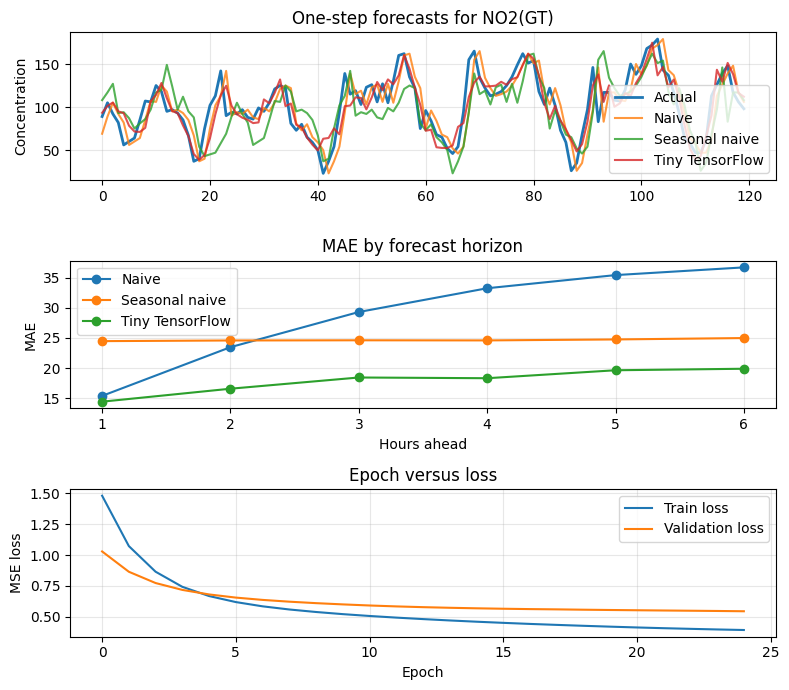

In [15]:
#@title Python Code - Baseline Forecasts

# Baseline forecasts start with simple rules.
# Civil engineering series often show persistence.
# We compare baselines with tiny neural forecasts.

# !pip install tensorflow==2.20.0

# Download the dataset in Colab.
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip

# Unzip the downloaded archive.
!unzip -o AirQualityUCI.zip

# Import core libraries safely.
import os, warnings, zipfile, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# Import metrics and TensorFlow.
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf

tf.get_logger().setLevel('ERROR')
print('TensorFlow version:', tf.__version__)

# Set deterministic random seeds.
np.random.seed(7)
random.seed(7)

tf.random.set_seed(7)

# Load the air quality table.
file_name = 'AirQualityUCI.csv'
df = pd.read_csv(file_name, sep=';', decimal=',')

extra_cols = ['Unnamed: 15', 'Unnamed: 16']
df = df.drop(columns=extra_cols, errors='ignore')

# Build a proper timestamp.
df['DateTime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],

    format='%d/%m/%Y %H.%M.%S',
    errors='coerce')

# Clean one pollutant series.
series_name = 'NO2(GT)'
df[series_name] = pd.to_numeric(df[series_name], errors='coerce')

df.loc[df[series_name] == -200, series_name] = np.nan
df = df[['DateTime', series_name]].dropna().sort_values('DateTime')

# Keep a manageable continuous subset.
df = df.reset_index(drop=True)
df = df.iloc[:1500].copy()

df[series_name] = df[series_name].interpolate(limit_direction='both')
values = df[series_name].to_numpy(dtype='float32')

# Check that enough data exists.
if len(values) < 300:
    raise ValueError('Not enough clean observations for forecasting.')

# Choose lags and forecast horizon.
lag_count = 24
horizon = 6

season_lag = 24

# Create supervised learning arrays.
X_list = []
y_list = []

for end_ix in range(lag_count, len(values) - horizon + 1):
    start_ix = end_ix - lag_count
    X_list.append(values[start_ix:end_ix])

    y_list.append(values[end_ix:end_ix + horizon])

# Convert lists into arrays.
X = np.array(X_list, dtype='float32')
y = np.array(y_list, dtype='float32')

if len(X) < 100:
    raise ValueError('Supervised dataset is too small.')

# Split data chronologically.
train_end = int(len(X) * 0.7)
val_end = int(len(X) * 0.85)

X_train = X[:train_end]
y_train = y[:train_end]
X_val = X[train_end:val_end]

y_val = y[train_end:val_end]

# Keep the final test block.
X_test = X[val_end:]
y_test = y[val_end:]

if len(X_test) < 20:
    raise ValueError('Test set is too small.')

# Build naive baseline forecasts.
naive_pred = np.zeros_like(y_test)
for i in range(len(X_test)):

    naive_pred[i, :] = X_test[i, -1]

# Build seasonal naive forecasts.
seasonal_pred = np.zeros_like(y_test)
for i in range(len(X_test)):

    seasonal_pred[i, :] = X_test[i, -season_lag:-season_lag + horizon]

# Scale inputs using training statistics.
train_mean = X_train.mean()
train_std = X_train.std()

if train_std == 0:
    train_std = 1.0
X_train_s = (X_train - train_mean) / train_std

X_val_s = (X_val - train_mean) / train_std
y_train_s = (y_train - train_mean) / train_std

y_val_s = (y_val - train_mean) / train_std
X_test_s = (X_test - train_mean) / train_std

# Build a tiny dense model.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(lag_count,)),

    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(horizon)])

# Compile the forecasting model.
model.compile(
    optimizer='adam',

    loss='mse')
history = model.fit(
    X_train_s, y_train_s,

    validation_data=(X_val_s, y_val_s),
    epochs=25, batch_size=32, verbose=0)

# Predict and unscale outputs.
tf_pred_s = model.predict(X_test_s, verbose=0)
tf_pred = tf_pred_s * train_std + train_mean

# Summarize horizon errors clearly.
summary_rows = []
for h in range(horizon):

    actual_h = y_test[:, h]
    naive_h = naive_pred[:, h]
    seasonal_h = seasonal_pred[:, h]

    tf_h = tf_pred[:, h]

    # Compute MAE for each horizon.
    row = {
        'H': h + 1,

        'Naive_MAE': mean_absolute_error(actual_h, naive_h),
        'Seasonal_MAE': mean_absolute_error(actual_h, seasonal_h),
        'TF_MAE': mean_absolute_error(actual_h, tf_h)}

    summary_rows.append(row)

# Create a compact summary table.
summary = pd.DataFrame(summary_rows)
summary = summary.round(2)

print('Series used:', series_name)
print('Test windows:', len(X_test), ' Horizon:', horizon)
print(summary.to_string(index=False))

# Compute overall test metrics.
naive_mae = mean_absolute_error(y_test.ravel(), naive_pred.ravel())
seasonal_mae = mean_absolute_error(y_test.ravel(), seasonal_pred.ravel())

tf_mae = mean_absolute_error(y_test.ravel(), tf_pred.ravel())
naive_rmse = np.sqrt(mean_squared_error(y_test.ravel(), naive_pred.ravel()))
seasonal_rmse = np.sqrt(mean_squared_error(y_test.ravel(), seasonal_pred.ravel()))

tf_rmse = np.sqrt(mean_squared_error(y_test.ravel(), tf_pred.ravel()))

# Print compact overall metrics.
print('Overall MAE:', round(naive_mae, 2), round(seasonal_mae, 2), round(tf_mae, 2))
print('Overall RMSE:', round(naive_rmse, 2), round(seasonal_rmse, 2), round(tf_rmse, 2))

# Prepare one-step comparison series.
plot_n = min(120, len(y_test))
actual_plot = y_test[:plot_n, 0]

naive_plot = naive_pred[:plot_n, 0]
seasonal_plot = seasonal_pred[:plot_n, 0]
tf_plot = tf_pred[:plot_n, 0]

# Create one figure with three panels.
fig, axes = plt.subplots(3, 1, figsize=(8, 7))
axes[0].plot(actual_plot, label='Actual', linewidth=2)

axes[0].plot(naive_plot, label='Naive', alpha=0.8)
axes[0].plot(seasonal_plot, label='Seasonal naive', alpha=0.8)
axes[0].plot(tf_plot, label='Tiny TensorFlow', alpha=0.8)

# Label the forecast comparison panel.
axes[0].set_title('One-step forecasts for NO2(GT)')
axes[0].set_ylabel('Concentration')

axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot horizon-by-horizon errors.
axes[1].plot(summary['H'], summary['Naive_MAE'], marker='o', label='Naive')
axes[1].plot(summary['H'], summary['Seasonal_MAE'], marker='o', label='Seasonal naive')

axes[1].plot(summary['H'], summary['TF_MAE'], marker='o', label='Tiny TensorFlow')
axes[1].set_title('MAE by forecast horizon')

# Label the error summary panel.
axes[1].set_xlabel('Hours ahead')
axes[1].set_ylabel('MAE')

axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot training and validation loss.
axes[2].plot(history.history['loss'], label='Train loss')
axes[2].plot(history.history['val_loss'], label='Validation loss')

axes[2].set_title('Epoch versus loss')
axes[2].set_xlabel('Epoch')

# Finish the learning curve panel.
axes[2].set_ylabel('MSE loss')
axes[2].legend()

axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **1.2. ARIMA Foundations**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_10/Lecture_B/image_01_02.jpg?v=1776653553" width="250">



>* ARIMA combines autoregression, differencing, and error correction.
>* It forecasts stable civil engineering time patterns.

>* Stationarity matters; differencing helps stabilize changing series.
>* ARIMA models recent patterns and shock effects.

>* Inspect data before choosing ARIMA approach.
>* Use engineering judgment when conditions change.



Archive:  AirQualityUCI.zip
  inflating: AirQualityUCI.csv       
  inflating: AirQualityUCI.xlsx      
TensorFlow version: 2.21.0
Autoregression uses recent values to predict the next value.
Here, lag features play the role of AR inputs.
Test MAE: 14.63
Lag diagram: t-24=76.0, t-3=63.0, t-2=63.0, t-1=63.0 -> t=84.0


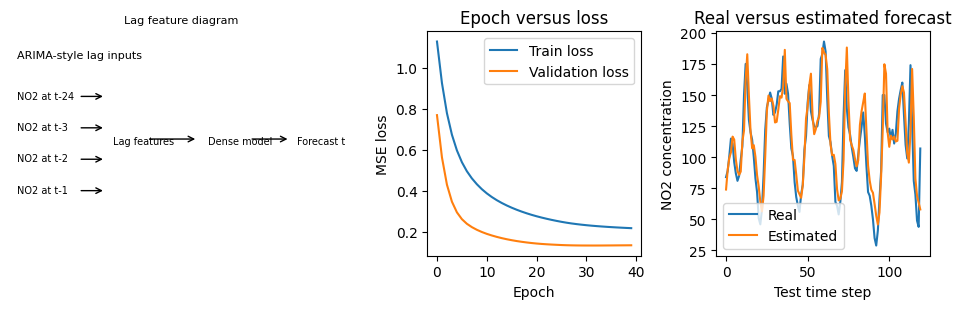

In [32]:
#@title Python Code - ARIMA Foundations

# ARIMA ideas start with past values.
# This example uses lagged air quality.
# Small dense networks mimic autoregressive forecasting.

# Install only if TensorFlow is missing.
# !pip install tensorflow==2.20.0

# Download the dataset in Colab.
# !wget https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip

# Unzip the downloaded archive.
!unzip -o AirQualityUCI.zip

# Silence TensorFlow warnings for beginners.
import os, warnings, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import numpy as np

# Import the main learning libraries.
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from sklearn.metrics import mean_absolute_error

# Reduce extra TensorFlow messages.
tf.get_logger().setLevel('ERROR')
np.random.seed(7)

random.seed(7)
tf.random.set_seed(7)

# Show the framework version briefly.
print('TensorFlow version:', tf.__version__)

# Load the air quality table.
df = pd.read_csv(
    'AirQualityUCI.csv',

    sep=';',
    decimal=',')

# Remove empty trailing columns safely.
df = df.dropna(axis=1, how='all')
df = df.loc[:, ~df.columns.str.contains('Unnamed')]

# Build a proper timestamp column.
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],

    format='%d/%m/%Y %H.%M.%S',
    errors='coerce')

# Replace missing markers with NaN.
df = df.replace(-200, np.nan)
df = df.sort_values('Datetime')

# Choose one engineering style signal.
series = df[['Datetime', 'NO2(GT)']].copy()
series = series.dropna()

series = series.rename(columns={'NO2(GT)': 'target'})

# Keep a manageable recent subset.
series = series.tail(900).reset_index(drop=True)
series['target'] = series['target'].interpolate()

series = series.dropna().reset_index(drop=True)

# Explain the autoregressive idea briefly.
print('Autoregression uses recent values to predict the next value.')
print('Here, lag features play the role of AR inputs.')

# Create simple lag features.
series['lag_1'] = series['target'].shift(1)
series['lag_2'] = series['target'].shift(2)

series['lag_3'] = series['target'].shift(3)
series['lag_24'] = series['target'].shift(24)

# Remove rows with incomplete lags.
series = series.dropna().reset_index(drop=True)

# Select inputs and target arrays.
feature_names = ['lag_1', 'lag_2', 'lag_3', 'lag_24']
X = series[feature_names].to_numpy(dtype='float32')

y = series['target'].to_numpy(dtype='float32')

# Check that enough rows remain.
if len(series) < 200:
    raise ValueError('Not enough clean rows for forecasting.')

# Split chronologically into train and test.
split_index = int(len(series) * 0.8)
X_train = X[:split_index]

X_test = X[split_index:]
y_train = y[:split_index]
y_test = y[split_index:]

# Standardize using training statistics.
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0) + 1e-6

y_mean = y_train.mean()
y_std = y_train.std() + 1e-6

# Apply the scaling transformation.
X_train_s = (X_train - X_mean) / X_std
X_test_s = (X_test - X_mean) / X_std

y_train_s = (y_train - y_mean) / y_std

# Build a tiny dense forecasting model.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),

    tf.keras.layers.Dense(12, activation='relu'),
    tf.keras.layers.Dense(1)])

# Compile with a simple optimizer.
model.compile(
    optimizer='adam',

    loss='mse')

# Train quietly for a few epochs.
history = model.fit(
    X_train_s,

    y_train_s,
    epochs=40,
    validation_split=0.2,

    verbose=0)

# Predict and return to original units.
pred_s = model.predict(X_test_s, verbose=0).reshape(-1)
pred = pred_s * y_std + y_mean

# Compute a beginner friendly error metric.
mae = mean_absolute_error(y_test, pred)
print('Test MAE:', round(float(mae), 2))

# Prepare a small lag diagram example.
example_row = series.iloc[split_index]
lag_text = (

    'Lag diagram: '
    + 't-24=' + str(round(example_row['lag_24'], 1))
    + ', t-3=' + str(round(example_row['lag_3'], 1))

    + ', t-2=' + str(round(example_row['lag_2'], 1))
    + ', t-1=' + str(round(example_row['lag_1'], 1))
    + ' -> t=' + str(round(example_row['target'], 1)))

print(lag_text)

# Create one figure with three teaching panels.
fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.2), gridspec_kw={'width_ratios': [1.6, 1, 1]})

# Draw a simple lag feature diagram.
axes[0].axis('off')
axes[0].set_xlim(0, 1)

axes[0].set_ylim(0, 1)
axes[0].text(0.02, 0.88, 'ARIMA-style lag inputs', fontsize=8)

axes[0].text(0.02, 0.70, 'NO2 at t-24', fontsize=7)
axes[0].text(0.02, 0.56, 'NO2 at t-3', fontsize=7)
axes[0].text(0.02, 0.42, 'NO2 at t-2', fontsize=7)

axes[0].text(0.02, 0.28, 'NO2 at t-1', fontsize=7)

axes[0].text(0.30, 0.50, 'Lag features', fontsize=7)
axes[0].text(0.58, 0.50, 'Dense model', fontsize=7)
axes[0].text(0.84, 0.50, 'Forecast t', fontsize=7)

axes[0].annotate('', (0.28, 0.71), (0.20, 0.71), arrowprops={'arrowstyle': '->'})
axes[0].annotate('', (0.28, 0.57), (0.20, 0.57), arrowprops={'arrowstyle': '->'})
axes[0].annotate('', (0.28, 0.43), (0.20, 0.43), arrowprops={'arrowstyle': '->'})

axes[0].annotate('', (0.28, 0.29), (0.20, 0.29), arrowprops={'arrowstyle': '->'})
axes[0].annotate('', (0.55, 0.52), (0.40, 0.52), arrowprops={'arrowstyle': '->'})
axes[0].annotate('', (0.82, 0.52), (0.70, 0.52), arrowprops={'arrowstyle': '->'})

axes[0].set_title('Lag feature diagram', fontsize=8)

# Plot epoch versus loss.
axes[1].plot(history.history['loss'], label='Train loss')
axes[1].plot(history.history['val_loss'], label='Validation loss')

axes[1].set_title('Epoch versus loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE loss')

axes[1].legend()

# Plot real versus estimated forecasts.
show_n = min(120, len(y_test))
axes[2].plot(y_test[:show_n], label='Real')

axes[2].plot(pred[:show_n], label='Estimated')
axes[2].set_title('Real versus estimated forecast')
axes[2].set_xlabel('Test time step')

axes[2].set_ylabel('NO2 concentration')
axes[2].legend()

# Finish the figure neatly.
plt.tight_layout()
plt.show()

### **1.3. Forecast Horizons**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_10/Lecture_B/image_01_03.jpg?v=1776653593" width="250">



>* Forecast horizon sets prediction time ahead.
>* Longer horizons increase uncertainty and reduce accuracy.

>* Match forecast horizon to decision needs.
>* Longer horizons reduce accuracy; model choice matters.

>* Horizons balance timeliness, accuracy, and decision value.
>* Choose models to fit the time scale.



--2026-04-20 21:10:35--  https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘AirQualityUCI.zip.12’

AirQualityUCI.zip.1     [  <=>               ]   1.47M  4.07MB/s    in 0.4s    

2026-04-20 21:10:35 (4.07 MB/s) - ‘AirQualityUCI.zip.12’ saved [1543989]

Archive:  AirQualityUCI.zip
  inflating: AirQualityUCI.csv       
  inflating: AirQualityUCI.xlsx      
TensorFlow version: 2.21.0
Horizon 1 MAE 11.89 RMSE 15.83
Horizon 6 MAE 20.2 RMSE 25.41
Horizon 24 MAE 23.69 RMSE 29.68


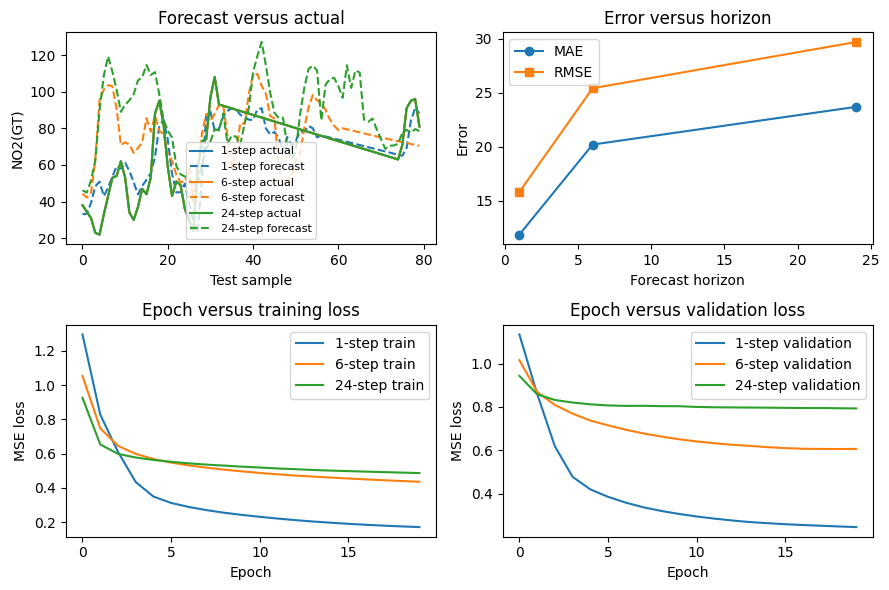

In [17]:
#@title Python Code - Forecast Horizons

# Forecast horizons change prediction difficulty.
# This example uses air quality data.
# Small models suit quick classroom demos.

# !pip install tensorflow==2.20.0

# Download the dataset in Colab.
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip

# Unzip the downloaded archive.
!unzip -o AirQualityUCI.zip

# Import quiet and essential libraries.
import os, warnings, random, zipfile
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# Import TensorFlow and metrics.
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error

tf.get_logger().setLevel('ERROR')

# Set deterministic random seeds.
np.random.seed(7)
random.seed(7)

tf.random.set_seed(7)

# Print one short environment line.
print('TensorFlow version:', tf.__version__)

# Load the air quality table.
df = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',')
extra_cols = ['Unnamed: 15', 'Unnamed: 16']

df = df.drop(columns=extra_cols, errors='ignore')

# Build a proper datetime column.
df['DateTime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],

    format='%d/%m/%Y %H.%M.%S',
    errors='coerce')

# Clean and sort the data.
df = df.sort_values('DateTime').reset_index(drop=True)
df = df.dropna(subset=['DateTime'])

df = df.replace(-200, np.nan)
signal = 'NO2(GT)'

# Keep one monitoring signal only.
series = df[['DateTime', signal]].copy()
series[signal] = pd.to_numeric(series[signal], errors='coerce')

series[signal] = series[signal].interpolate(limit_direction='both')
series = series.dropna().reset_index(drop=True)

# Reduce size for faster teaching runs.
series = series.iloc[:2500].copy()
values = series[signal].to_numpy(dtype='float32')

if len(values) < 400:
    raise ValueError('Dataset became too small.')

# Split chronologically into train and test.
split = int(len(values) * 0.8)
train_vals = values[:split]

test_vals = values[split:]
mean_val = train_vals.mean()
std_val = train_vals.std() + 1e-6

# Standardize using training statistics.
scaled = (values - mean_val) / std_val
lookback = 24

horizons = [1, 6, 24]

# Create lagged samples for one horizon.
def make_xy(arr, steps, horizon):
    xs = []

    ys = []
    end = len(arr) - steps - horizon + 1
    for i in range(end):

        xs.append(arr[i:i + steps])
        ys.append(arr[i + steps + horizon - 1])
    return np.array(xs), np.array(ys)

# Train one tiny dense model.
def train_model(x_train, y_train):
    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=(lookback,)),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(8, activation='relu'),

        tf.keras.layers.Dense(1)])
    model.compile(optimizer='adam', loss='mse')
    history = model.fit(

        x_train, y_train,
        epochs=20, batch_size=32,
        validation_split=0.2, verbose=0)

    return model, history

# Store results for each horizon.
results = {}
loss_histories = {}

# Train and evaluate each horizon.
for horizon in horizons:
    x_all, y_all = make_xy(scaled, lookback, horizon)

    cut = split - lookback - horizon + 1
    x_train = x_all[:cut]
    y_train = y_all[:cut]

    x_test = x_all[cut:]
    y_test = y_all[cut:]

    # Check sample sizes safely.
    if len(x_train) < 100 or len(x_test) < 20:
        raise ValueError('Not enough samples for horizon.')

    model, history = train_model(x_train, y_train)
    pred_scaled = model.predict(x_test, verbose=0).reshape(-1)

    # Convert back to original units.
    y_true = y_test * std_val + mean_val
    y_pred = pred_scaled * std_val + mean_val

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # Save compact outputs.
    results[horizon] = {}
    results[horizon]['true'] = y_true

    results[horizon]['pred'] = y_pred
    results[horizon]['mae'] = mae
    results[horizon]['rmse'] = rmse

    loss_histories[horizon] = history.history

# Print a short metric summary.
for horizon in horizons:
    mae = round(results[horizon]['mae'], 2)

    rmse = round(results[horizon]['rmse'], 2)
    print('Horizon', horizon, 'MAE', mae, 'RMSE', rmse)

# Create one figure with all plots.
fig, axes = plt.subplots(2, 2, figsize=(9, 6))
show_n = 80

colors = ['tab:blue', 'tab:orange', 'tab:green']

# Plot forecast versus actual lines.
ax = axes[0, 0]
for i in range(len(horizons)):

    horizon = horizons[i]
    y_true = results[horizon]['true'][:show_n]
    y_pred = results[horizon]['pred'][:show_n]

    ax.plot(y_true, color=colors[i], linestyle='-', label=str(horizon) + '-step actual')
    ax.plot(y_pred, color=colors[i], linestyle='--', label=str(horizon) + '-step forecast')
ax.set_title('Forecast versus actual')

ax.set_xlabel('Test sample')
ax.set_ylabel(signal)
ax.legend(fontsize=8)

# Plot error versus horizon.
ax = axes[0, 1]
maes = [results[h]['mae'] for h in horizons]

rmses = [results[h]['rmse'] for h in horizons]
ax.plot(horizons, maes, marker='o', label='MAE')
ax.plot(horizons, rmses, marker='s', label='RMSE')

ax.set_title('Error versus horizon')
ax.set_xlabel('Forecast horizon')
ax.set_ylabel('Error')

ax.legend()

# Plot training loss curves.
ax = axes[1, 0]
for i in range(len(horizons)):

    horizon = horizons[i]
    loss = loss_histories[horizon]['loss']
    ax.plot(loss, color=colors[i], label=str(horizon) + '-step train')

ax.set_title('Epoch versus training loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')

ax.legend()

# Plot validation loss curves.
ax = axes[1, 1]
for i in range(len(horizons)):

    horizon = horizons[i]
    val_loss = loss_histories[horizon]['val_loss']
    ax.plot(val_loss, color=colors[i], label=str(horizon) + '-step validation')

ax.set_title('Epoch versus validation loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')

ax.legend()

# Finish the teaching figure.
plt.tight_layout()
plt.show()

## **2. Anomaly Detection Methods**

### **2.1. Z score thresholds**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_10/Lecture_B/image_02_01.jpg?v=1776653642" width="250">



>* Z scores measure how unusual values are.
>* Larger absolute scores more strongly suggest anomalies.

>* Use context-specific baselines for reliable detection.
>* High Z scores may reflect non-damage issues.

>* Thresholds trade early detection against false alarms.
>* Use Z scores with context and judgement.



Signal: NO2(GT)
Rows used: 800
Rolling window: 24 hours
Alerts at |Z| > 2: 28
Alerts at |Z| > 3: 0
Lower threshold finds more unusual points.


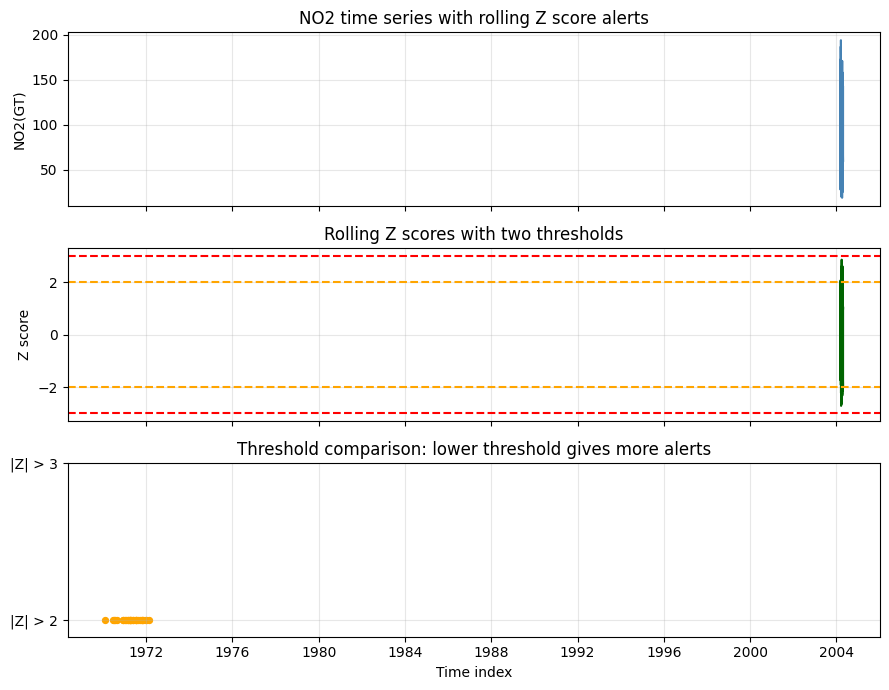

In [18]:
#@title Python Code - Z score thresholds

# This example shows rolling Z score alerts.
# Air quality data supports civil monitoring ideas.
# Thresholds change anomaly sensitivity and false alarms.

# Import beginner friendly analysis libraries.
import zipfile
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt

# Set deterministic values for repeatability.
np.random.seed(7)
pd.options.mode.chained_assignment = None

plt.rcParams["figure.figsize"] = (9, 7)

# Download the dataset in Colab first.
# !wget https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip
zip_path = "AirQualityUCI.zip"

csv_path = "AirQualityUCI.csv"

# Unzip only when the csv is missing.
if not pd.io.common.file_exists(csv_path):
    with zipfile.ZipFile(zip_path, "r") as zf:

        zf.extractall(".")

# Load the air quality time series.
df = pd.read_csv(
    csv_path,

    sep=";",
    decimal=",")

# Remove empty trailing columns safely.
df = df.dropna(axis=1, how="all")
df = df.loc[:, ~df.columns.str.contains("Unnamed")]

value_name = "NO2(GT)"

# Build a proper datetime column.
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],

    format="%d/%m/%Y %H.%M.%S",
    errors="coerce")

# Clean missing codes and sort time.
df[value_name] = pd.to_numeric(df[value_name], errors="coerce")
df.loc[df[value_name] == -200, value_name] = np.nan

df = df.dropna(subset=["Datetime", value_name])
df = df.sort_values("Datetime").reset_index(drop=True)

# Keep a manageable continuous sample.
series = df[["Datetime", value_name]].copy()
series = series.iloc[:800].reset_index(drop=True)

window = 24

# Compute rolling baseline statistics.
rolling_mean = series[value_name].rolling(window=window).mean()
rolling_std = series[value_name].rolling(window=window).std()

rolling_std = rolling_std.replace(0, np.nan)
series["z_score"] = (
    (series[value_name] - rolling_mean) / rolling_std)

# Compare two threshold choices.
series["alert_2"] = series["z_score"].abs() > 2.0
series["alert_3"] = series["z_score"].abs() > 3.0

count_2 = int(series["alert_2"].sum())
count_3 = int(series["alert_3"].sum())

# Print a short teaching summary.
print("Signal:", value_name)
print("Rows used:", len(series))

print("Rolling window:", window, "hours")
print("Alerts at |Z| > 2:", count_2)
print("Alerts at |Z| > 3:", count_3)

print("Lower threshold finds more unusual points.")

# Create one figure with three teaching panels.
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)

# Plot the signal with stricter alerts.
axes[0].plot(series["Datetime"], series[value_name], color="steelblue")
axes[0].scatter(

    series.loc[series["alert_3"], "Datetime"],
    series.loc[series["alert_3"], value_name],
    color="crimson",

    s=28)
axes[0].set_title("NO2 time series with rolling Z score alerts")
axes[0].set_ylabel("NO2(GT)")

axes[0].grid(True, alpha=0.3)

# Plot rolling Z scores and thresholds.
axes[1].plot(series["Datetime"], series["z_score"], color="darkgreen")
axes[1].axhline(2.0, color="orange", linestyle="--")

axes[1].axhline(-2.0, color="orange", linestyle="--")
axes[1].axhline(3.0, color="red", linestyle="--")
axes[1].axhline(-3.0, color="red", linestyle="--")

axes[1].set_title("Rolling Z scores with two thresholds")
axes[1].set_ylabel("Z score")
axes[1].grid(True, alpha=0.3)

# Plot threshold sensitivity as alert markers.
idx2 = np.where(series["alert_2"].fillna(False))[0]
idx3 = np.where(series["alert_3"].fillna(False))[0]

axes[2].scatter(idx2, np.ones(len(idx2)) * 2, color="orange", s=18)
axes[2].scatter(idx3, np.ones(len(idx3)) * 3, color="red", s=18)
axes[2].set_title("Threshold comparison: lower threshold gives more alerts")

axes[2].set_yticks([2, 3])
axes[2].set_yticklabels(["|Z| > 2", "|Z| > 3"])
axes[2].set_xlabel("Time index")

axes[2].grid(True, alpha=0.3)

# Finish the figure neatly.
plt.tight_layout()
plt.show()

### **2.2. Threshold Alert Rules**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_10/Lecture_B/image_02_02.jpg?v=1776653682" width="250">



>* Thresholds flag values outside acceptable limits.
>* Simple rules support quick engineering decisions.

>* Fixed thresholds can miss context-dependent anomalies.
>* Use contextual and persistent alerts reduce false alarms.

>* Alerts need context for maintenance decisions.
>* Balanced thresholds reduce missed events and false alarms.



--2026-04-20 21:10:42--  https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘AirQualityUCI.zip.13’

AirQualityUCI.zip.1     [  <=>               ]   1.47M  4.00MB/s    in 0.4s    

2026-04-20 21:10:42 (4.00 MB/s) - ‘AirQualityUCI.zip.13’ saved [1543989]

Archive:  AirQualityUCI.zip
  inflating: AirQualityUCI.csv       
  inflating: AirQualityUCI.xlsx      
TensorFlow version: 2.21.0
Rows used: 1200
         Method  Alert count
Threshold rules           13
   TF residuals           11
Test MAE: 1.453
Test RMSE: 1.805


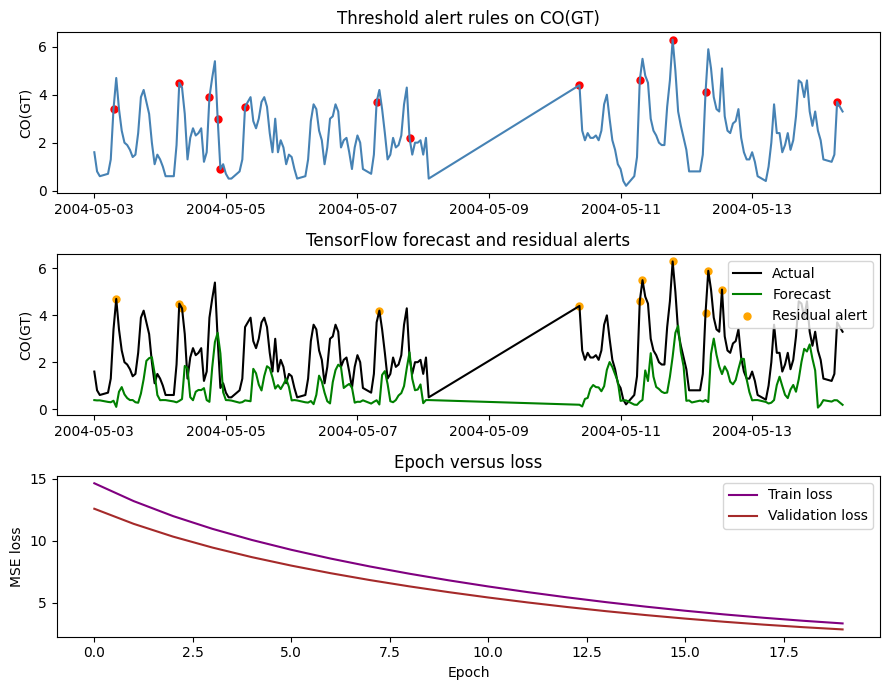

In [19]:
#@title Python Code - Threshold Alert Rules

# Threshold rules flag unusual sensor behavior.
# This example uses air quality time series.
# We compare rules with residual alerts.

# !pip install tensorflow==2.20.0

# Download the dataset in Colab.
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip

# Unzip the downloaded archive.
!unzip -o AirQualityUCI.zip

# Import core learning libraries.
import os, warnings, zipfile
import numpy as np, pandas as pd

import matplotlib.pyplot as plt
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Silence extra TensorFlow warnings.
warnings.filterwarnings('ignore')
import tensorflow as tf

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# Reduce TensorFlow console messages.
tf.get_logger().setLevel('ERROR')
np.random.seed(7)

tf.random.set_seed(7)
print('TensorFlow version:', tf.__version__)

# Load the air quality file.
file_name = 'AirQualityUCI.csv'
df = pd.read_csv(file_name, sep=';', decimal=',')

keep_cols = ['Date', 'Time', 'CO(GT)', 'NO2(GT)', 'PT08.S1(CO)']
df = df[keep_cols].copy()

# Build a proper timestamp column.
df['datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],

    format='%d/%m/%Y %H.%M.%S',
    errors='coerce')

# Clean missing and invalid values.
df = df.dropna(subset=['datetime'])
df = df.replace(-200, np.nan)

df['CO(GT)'] = pd.to_numeric(df['CO(GT)'], errors='coerce')
df['NO2(GT)'] = pd.to_numeric(df['NO2(GT)'], errors='coerce')

# Keep rows with needed signals.
df = df.dropna(subset=['CO(GT)', 'NO2(GT)', 'PT08.S1(CO)'])
df = df.sort_values('datetime').reset_index(drop=True)

df = df.iloc[:1200].copy()
print('Rows used:', len(df))

# Create simple rule based alerts.
df['co_change'] = df['CO(GT)'].diff().abs()
rule_high = df['CO(GT)'] > 6.0

rule_jump = df['co_change'] > 2.0
rule_combo = (df['NO2(GT)'] > 180) & (df['PT08.S1(CO)'] > 1400)

# Combine all threshold alerts.
df['rule_alert'] = rule_high | rule_jump | rule_combo
df['rule_alert'] = df['rule_alert'].fillna(False)

# Build lag features for forecasting.
df['lag1'] = df['CO(GT)'].shift(1)
df['lag2'] = df['CO(GT)'].shift(2)

df['lag24'] = df['CO(GT)'].shift(24)
df['hour'] = df['datetime'].dt.hour

# Keep rows with complete lags.
model_df = df.dropna().copy()
features = ['lag1', 'lag2', 'lag24', 'hour']

X = model_df[features].to_numpy(dtype='float32')
y = model_df['CO(GT)'].to_numpy(dtype='float32')

# Split data in time order.
split = int(len(model_df) * 0.8)
X_train = X[:split]

X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

# Scale inputs using training values.
mean_x = X_train.mean(axis=0)
std_x = X_train.std(axis=0) + 1e-6

X_train = (X_train - mean_x) / std_x
X_test = (X_test - mean_x) / std_x

# Create a tiny forecasting model.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),

    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1)])

# Compile and train silently.
model.compile(optimizer='adam', loss='mse')
history = model.fit(

    X_train, y_train,
    epochs=20,
    batch_size=32,

    validation_split=0.2,
    verbose=0)

# Predict future carbon monoxide values.
pred_test = model.predict(X_test, verbose=0).reshape(-1)
residuals = np.abs(y_test - pred_test)

resid_limit = residuals.mean() + 2.0 * residuals.std()

# Mark residual based alerts.
test_df = model_df.iloc[split:].copy()
test_df['pred_co'] = pred_test

test_df['residual'] = residuals
test_df['tf_alert'] = test_df['residual'] > resid_limit

# Compute simple forecast errors.
mae = mean_absolute_error(y_test, pred_test)
rmse = np.sqrt(mean_squared_error(y_test, pred_test))

# Summarize alert counts by method.
summary = pd.DataFrame({
    'Method': ['Threshold rules', 'TF residuals'],

    'Alert count': [int(test_df['rule_alert'].sum()), int(test_df['tf_alert'].sum())]})
print(summary.to_string(index=False))
print('Test MAE:', round(mae, 3))

print('Test RMSE:', round(rmse, 3))

# Create one figure with three panels.
fig, axes = plt.subplots(3, 1, figsize=(9, 7))
plot_df = test_df.iloc[:200].copy()

# Plot threshold alerts on observations.
axes[0].plot(plot_df['datetime'], plot_df['CO(GT)'], color='steelblue')
axes[0].scatter(

    plot_df.loc[plot_df['rule_alert'], 'datetime'],
    plot_df.loc[plot_df['rule_alert'], 'CO(GT)'],
    color='red', s=25)

axes[0].set_title('Threshold alert rules on CO(GT)')
axes[0].set_ylabel('CO(GT)')

# Plot residual alerts on forecasts.
axes[1].plot(plot_df['datetime'], plot_df['CO(GT)'], label='Actual', color='black')
axes[1].plot(plot_df['datetime'], plot_df['pred_co'], label='Forecast', color='green')

axes[1].scatter(
    plot_df.loc[plot_df['tf_alert'], 'datetime'],
    plot_df.loc[plot_df['tf_alert'], 'CO(GT)'],

    color='orange', s=25, label='Residual alert')
axes[1].set_title('TensorFlow forecast and residual alerts')
axes[1].set_ylabel('CO(GT)')

axes[1].legend(loc='upper right')

# Plot training and validation loss.
axes[2].plot(history.history['loss'], label='Train loss', color='purple')
axes[2].plot(history.history['val_loss'], label='Validation loss', color='brown')

axes[2].set_title('Epoch versus loss')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('MSE loss')

axes[2].legend(loc='upper right')

# Show the final teaching figure.
plt.tight_layout()
plt.show()

### **2.3. Maintenance Decision Context**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_10/Lecture_B/image_02_03.jpg?v=1776653723" width="250">



>* Anomalies matter only in maintenance context.
>* Interpret signals by asset risk and cause.

>* Not every anomaly needs maintenance action.
>* Use context and trends to judge urgency.

>* Anomalies help prioritise maintenance, not diagnose.
>* Assess persistence, severity, and inspection urgency.



--2026-04-20 21:10:44--  https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘AirQualityUCI.zip.14’

AirQualityUCI.zip.1     [  <=>               ]   1.47M  3.45MB/s    in 0.4s    

2026-04-20 21:10:45 (3.45 MB/s) - ‘AirQualityUCI.zip.14’ saved [1543989]

Rows used: 989
Alert hours: 47
Isolated events: 23
Sustained events: 5
       day  score                      action
2004-03-19      7 Schedule maintenance review
2004-03-17      7 Schedule maintenance review
2004-04-07      4       Check sensor and site
2004-03-11      3       Check sensor and site
2004-04-24      3       Check sensor and site


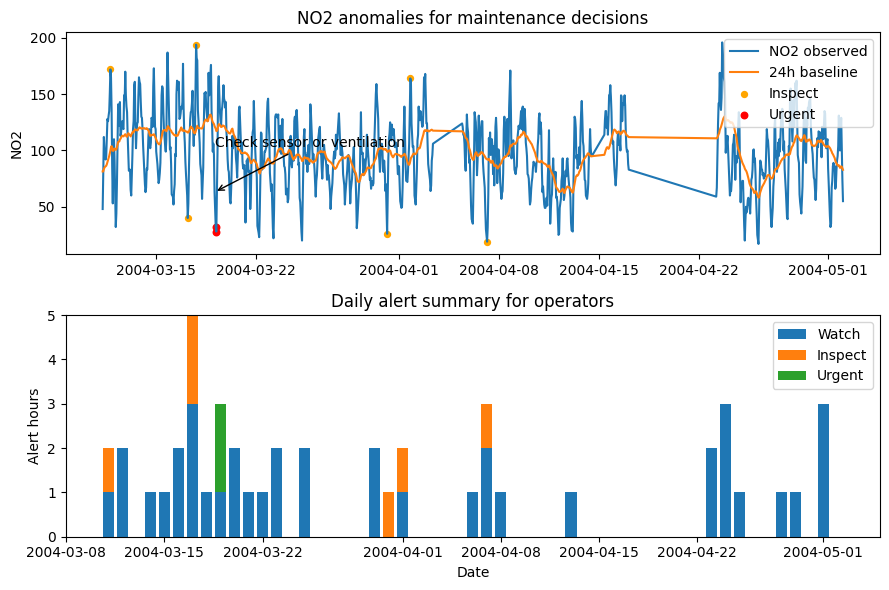

In [20]:
#@title Python Code - Maintenance Decision Context

# Air quality alerts guide maintenance choices.
# This example uses simple anomaly rules.
# Results support operator friendly decisions.

import zipfile, random, datetime as dt
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# Set seeds for repeatable results.
np.random.seed(7)
random.seed(7)

# Download the dataset in Colab.
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip

# Unzip the downloaded archive.
with zipfile.ZipFile("AirQualityUCI.zip", "r") as zf:
    zf.extractall(".")

# Load the semicolon separated file.
df = pd.read_csv(
    "AirQualityUCI.csv",

    sep=";",
    decimal=",")

# Remove empty trailing columns.
df = df.dropna(axis=1, how="all")

# Build a timestamp column.
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],

    format="%d/%m/%Y %H.%M.%S",
    errors="coerce")

# Keep one pollutant for simple teaching.
df["NO2"] = pd.to_numeric(df["NO2(GT)"], errors="coerce")

# Replace dataset missing code values.
df.loc[df["NO2"] == -200, "NO2"] = np.nan

# Keep valid rows and sort time.
df = df[["Datetime", "NO2"]].dropna()
df = df.sort_values("Datetime").reset_index(drop=True)

# Use a manageable continuous sample.
df = df.iloc[:1000].copy()

# Create a simple baseline forecast.
df["forecast"] = df["NO2"].rolling(24, min_periods=12).mean()

# Compute residuals from the baseline.
df["residual"] = df["NO2"] - df["forecast"]

df = df.dropna().reset_index(drop=True)

# Standardize residuals with Z scores.
res_mean = df["residual"].mean()
res_std = df["residual"].std()

df["z_score"] = (df["residual"] - res_mean) / res_std

df["abs_z"] = df["z_score"].abs()

# Group alerts into severity bands.
df["severity"] = "Normal"
df.loc[df["abs_z"] >= 2.0, "severity"] = "Watch"

df.loc[df["abs_z"] >= 2.5, "severity"] = "Inspect"
df.loc[df["abs_z"] >= 3.0, "severity"] = "Urgent"

# Mark alert rows for event grouping.
df["alert_flag"] = df["severity"] != "Normal"

# Find consecutive alert events.
df["event_id"] = (
    df["alert_flag"] != df["alert_flag"].shift(1)

).cumsum()

# Summarize only alert events.
events = df[df["alert_flag"]].groupby("event_id").agg(
    start_time=("Datetime", "min"),

    end_time=("Datetime", "max"),
    hours=("Datetime", "size"),
    peak_z=("abs_z", "max"),

    peak_level=("severity", "max")
).reset_index(drop=True)

# Label sustained and isolated events.
events["event_type"] = "Isolated"
events.loc[events["hours"] >= 3, "event_type"] = "Sustained"

# Build a daily operator summary.
df["day"] = df["Datetime"].dt.date

daily = df.groupby("day").agg(
    watch_hours=("severity", lambda s: (s == "Watch").sum()),
    inspect_hours=("severity", lambda s: (s == "Inspect").sum()),

    urgent_hours=("severity", lambda s: (s == "Urgent").sum())
).reset_index()

# Create a simple action score.
daily["score"] = (
    daily["watch_hours"]

    + 2 * daily["inspect_hours"]
    + 3 * daily["urgent_hours"])

# Convert score into operator actions.
daily["action"] = "Continue monitoring"
daily.loc[daily["score"] >= 3, "action"] = "Check sensor and site"

daily.loc[daily["score"] >= 6, "action"] = "Schedule maintenance review"
daily.loc[daily["score"] >= 10, "action"] = "Immediate inspection"

# Prepare a small decision table.
decision = daily[daily["score"] > 0].copy()
decision = decision.sort_values("score", ascending=False)

decision = decision.head(5)

# Count sustained and isolated events.
isolated_count = 0
sustained_count = 0

if len(events) > 0:
    isolated_count = (events["event_type"] == "Isolated").sum()
    sustained_count = (events["event_type"] == "Sustained").sum()

# Print a short operator summary.
print("Rows used:", len(df))
print("Alert hours:", int(df["alert_flag"].sum()))

print("Isolated events:", int(isolated_count))
print("Sustained events:", int(sustained_count))

# Print a compact decision table.
if len(decision) > 0:
    print(decision[["day", "score", "action"]].to_string(index=False))

else:
    print("No alert days in this sample.")

# Create one figure with two panels.
fig, axes = plt.subplots(2, 1, figsize=(9, 6))

# Plot measurements and highlighted alerts.
axes[0].plot(df["Datetime"], df["NO2"], label="NO2 observed")
axes[0].plot(df["Datetime"], df["forecast"], label="24h baseline")

# Highlight severe points for operators.
urgent = df[df["severity"] == "Urgent"]
inspect = df[df["severity"] == "Inspect"]

axes[0].scatter(
    inspect["Datetime"],
    inspect["NO2"],

    color="orange",
    s=18,
    label="Inspect")

axes[0].scatter(
    urgent["Datetime"],
    urgent["NO2"],

    color="red",
    s=22,
    label="Urgent")

# Add one annotation for context.
if len(events) > 0:
    top_event = events.sort_values("peak_z", ascending=False).iloc[0]

    note_time = top_event["start_time"]
    note_row = df[df["Datetime"] == note_time].iloc[0]
    axes[0].annotate(

        "Check sensor or ventilation",
        xy=(note_row["Datetime"], note_row["NO2"]),
        xytext=(note_row["Datetime"], note_row["NO2"] + 40),

        arrowprops={"arrowstyle": "->"})

# Format the first panel.
axes[0].set_title("NO2 anomalies for maintenance decisions")
axes[0].set_ylabel("NO2")

axes[0].legend(loc="upper right")

# Plot daily alert hours by severity.
bar_days = pd.to_datetime(daily["day"])
axes[1].bar(bar_days, daily["watch_hours"], label="Watch")

axes[1].bar(
    bar_days,
    daily["inspect_hours"],

    bottom=daily["watch_hours"],
    label="Inspect")
axes[1].bar(

    bar_days,
    daily["urgent_hours"],
    bottom=daily["watch_hours"] + daily["inspect_hours"],

    label="Urgent")

# Format the second panel.
axes[1].set_title("Daily alert summary for operators")
axes[1].set_ylabel("Alert hours")

axes[1].set_xlabel("Date")
axes[1].legend(loc="upper right")

# Tight layout improves readability.
plt.tight_layout()
plt.show()

## **3. Evaluating Results**

### **3.1. Forecast Error Metrics**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_10/Lecture_B/image_03_01.jpg?v=1776653771" width="250">



>* Error metrics numerically compare forecast accuracy.
>* Interpret errors using context, scale, consequences.

>* Choose metrics based on decision needs.
>* Compare against baselines, not error alone.

>* Check when errors happen, not averages.
>* Compare horizons using plots and metrics.



--2026-04-20 21:10:45--  https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘AirQualityUCI.zip.15’

AirQualityUCI.zip.1     [  <=>               ]   1.47M  4.08MB/s    in 0.4s    

2026-04-20 21:10:46 (4.08 MB/s) - ‘AirQualityUCI.zip.15’ saved [1543989]

Archive:  AirQualityUCI.zip
  inflating: AirQualityUCI.csv       
  inflating: AirQualityUCI.xlsx      
TensorFlow version: 2.21.0
Target variable: CO(GT)
Test samples: 222
       Naive  TensorFlow
MAE    0.561       0.500
RMSE   0.848       0.659
MAPE  35.927      40.793
R2     0.488       0.691


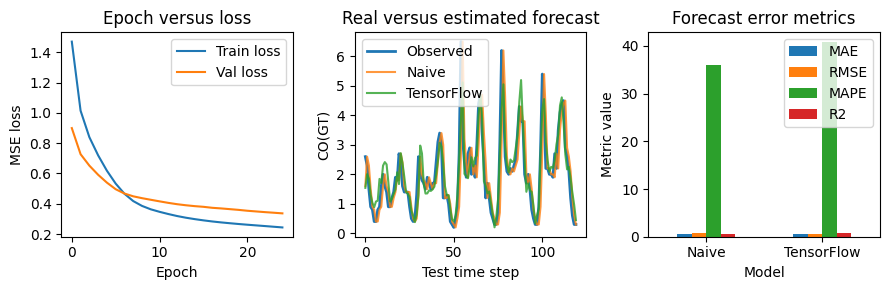

In [21]:
#@title Python Code - Forecast Error Metrics

# Forecast errors guide engineering model choices.
# Air quality data supports time forecasting.
# We compare baseline and neural forecasts.

# !pip install tensorflow==2.20.0

# Download the dataset in Colab.
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip

# Unzip the downloaded archive safely.
!unzip -o AirQualityUCI.zip

# Import core libraries for analysis.
import os, warnings, random, math
import numpy as np, pandas as pd

import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Import extra metrics for evaluation.
from sklearn.metrics import r2_score

# Reduce TensorFlow warning messages.
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

# Set seeds for reproducible results.
np.random.seed(7)
random.seed(7)

tf.random.set_seed(7)

# Show the TensorFlow version briefly.
print('TensorFlow version:', tf.__version__)

# Load the air quality file.
file_name = 'AirQualityUCI.csv'
df = pd.read_csv(file_name, sep=';', decimal=',')

# Remove empty trailing columns.
df = df.dropna(axis=1, how='all')

# Replace missing value markers.
df = df.replace(-200, np.nan)

# Build a proper datetime column.
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],

    format='%d/%m/%Y %H.%M.%S',
    errors='coerce')

# Keep one useful forecasting variable.
series_name = 'CO(GT)'
df = df[['Datetime', series_name]].copy()

df = df.dropna().sort_values('Datetime')
df = df.reset_index(drop=True)

# Smooth short gaps if needed.
df[series_name] = df[series_name].interpolate(limit_direction='both')

# Keep a manageable continuous subset.
df = df.iloc[:1500].copy()

# Create lagged supervised examples.
window = 24
values = df[series_name].to_numpy(dtype='float32')

# Prepare lists for sequences.
X_list = []
y_list = []

# Build rolling windows carefully.
for i in range(window, len(values)):
    X_list.append(values[i - window:i])

    y_list.append(values[i])

# Convert lists into arrays.
X = np.array(X_list, dtype='float32')
y = np.array(y_list, dtype='float32')

# Stop if data is insufficient.
if len(X) < 200:
    raise ValueError('Not enough clean rows for forecasting.')

# Split data chronologically.
train_end = int(len(X) * 0.7)
val_end = int(len(X) * 0.85)

# Create train validation test sets.
X_train = X[:train_end]
y_train = y[:train_end]

X_val = X[train_end:val_end]
y_val = y[train_end:val_end]
X_test = X[val_end:]

y_test = y[val_end:]

# Scale using training statistics only.
mean_x = X_train.mean()
std_x = X_train.std() + 1e-6

mean_y = y_train.mean()
std_y = y_train.std() + 1e-6

# Apply standardization to inputs.
X_train_s = (X_train - mean_x) / std_x
X_val_s = (X_val - mean_x) / std_x

X_test_s = (X_test - mean_x) / std_x

# Apply standardization to targets.
y_train_s = (y_train - mean_y) / std_y
y_val_s = (y_val - mean_y) / std_y

# Reshape arrays for TensorFlow.
X_train_s = X_train_s[..., np.newaxis]
X_val_s = X_val_s[..., np.newaxis]

X_test_s = X_test_s[..., np.newaxis]

# Build a small forecasting network.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(window, 1)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),

    tf.keras.layers.Dense(1)])

# Compile the model simply.
model.compile(
    optimizer='adam',

    loss='mse',
    metrics=['mae'])

# Add early stopping for speed.
stopper = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',

    patience=5,
    restore_best_weights=True)

# Train quietly on small data.
history = model.fit(
    X_train_s, y_train_s,

    validation_data=(X_val_s, y_val_s),
    epochs=25,
    batch_size=32,

    verbose=0,
    callbacks=[stopper])

# Create naive baseline predictions.
naive_pred = X_test[:, -1]

# Predict with the neural model.
model_pred_s = model.predict(X_test_s, verbose=0).reshape(-1)
model_pred = model_pred_s * std_y + mean_y

# Define a safe percentage metric.
def safe_mape(y_true, y_pred):

    mask = np.abs(y_true) > 1e-6
    if mask.sum() == 0:
        return np.nan

    value = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

    return 100 * value

# Compute common forecast metrics.
def metric_row(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = safe_mape(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)

    return [mae, rmse, mape, r2]

# Store metrics in a table.
metric_names = ['MAE', 'RMSE', 'MAPE', 'R2']
naive_scores = metric_row(y_test, naive_pred)

model_scores = metric_row(y_test, model_pred)

# Build a compact results frame.
results = pd.DataFrame(
    {'Naive': naive_scores, 'TensorFlow': model_scores},

    index=metric_names)

# Print a short metric summary.
print('Target variable:', series_name)
print('Test samples:', len(y_test))

print(results.round(3))

# Prepare a single figure with subplots.
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

# Plot training and validation loss.
axes[0].plot(history.history['loss'], label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')

axes[0].set_title('Epoch versus loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE loss')

axes[0].legend()

# Plot actual and predicted values.
show_n = min(120, len(y_test))
axes[1].plot(y_test[:show_n], label='Observed', linewidth=2)

axes[1].plot(naive_pred[:show_n], label='Naive', alpha=0.8)
axes[1].plot(model_pred[:show_n], label='TensorFlow', alpha=0.8)
axes[1].set_title('Real versus estimated forecast')

axes[1].set_xlabel('Test time step')
axes[1].set_ylabel(series_name)
axes[1].legend()

# Plot a bar chart of metrics.
bar_data = results.copy()
bar_data.loc['R2'] = bar_data.loc['R2'].clip(lower=-1, upper=1)

bar_data.T.plot(kind='bar', ax=axes[2])
axes[2].set_title('Forecast error metrics')
axes[2].set_xlabel('Model')

axes[2].set_ylabel('Metric value')
axes[2].tick_params(axis='x', rotation=0)

# Finish the figure neatly.
plt.tight_layout()
plt.show()

### **3.2. Anomaly Visualization**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_10/Lecture_B/image_03_02.jpg?v=1776653816" width="250">



>* Visuals add context to flagged anomalies.
>* They separate real issues from normal events.

>* Compare anomalies with patterns and limits.
>* Visual checks reduce false alarms, validate rules.

>* Visuals explain alerts for different audiences.
>* They support judgment beyond numerical outputs.



Signal: NO2(GT)
Rows used: 7715
Anomalies found: 48
Threshold |z| > 3.0


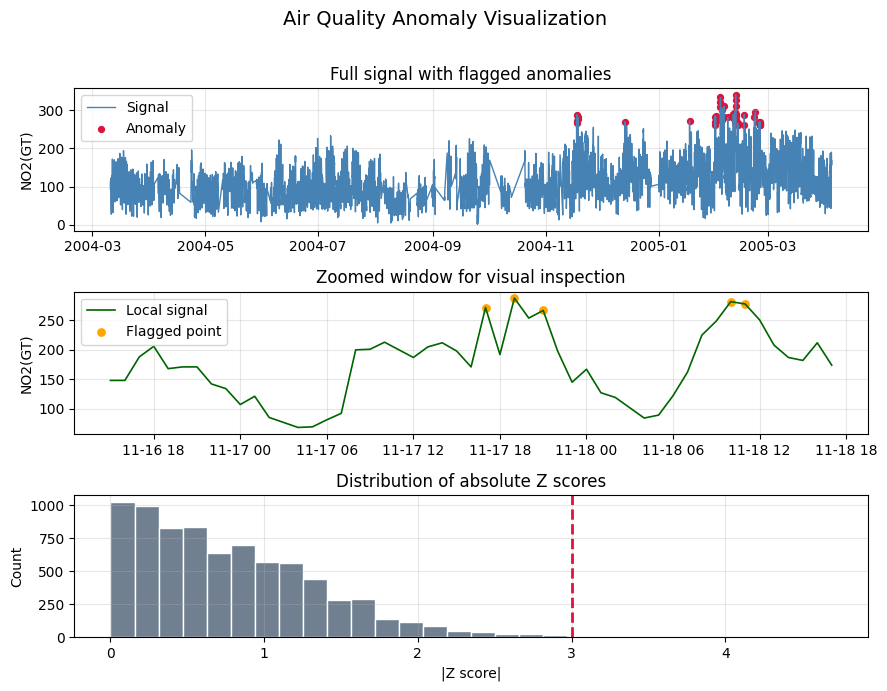

In [22]:
#@title Python Code - Anomaly Visualization

# Visualize anomalies in air quality signals.
# This example supports engineering result evaluation.
# We inspect scores, context, and flagged points.

# Install lines are unnecessary here.

# Download the dataset in Colab first.
# !wget https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip

# Import beginner friendly libraries.
import zipfile
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt

# Set a deterministic random seed.
np.random.seed(7)

# Open the downloaded zip file.
zip_path = "AirQualityUCI.zip"
zip_file = zipfile.ZipFile(zip_path, "r")

file_names = zip_file.namelist()
csv_name = "AirQualityUCI.csv"

# Read the semicolon separated file.
if csv_name not in file_names:
    csv_name = file_names[0]

raw = pd.read_csv(
    zip_file.open(csv_name),
    sep=";",

    decimal=",")

# Remove empty trailing columns safely.
raw = raw.dropna(axis=1, how="all")
raw.columns = [col.strip() for col in raw.columns]

# Build a proper timestamp column.
raw["Date"] = raw["Date"].astype(str).str.strip()
raw["Time"] = raw["Time"].astype(str).str.strip()

raw["timestamp"] = pd.to_datetime(
    raw["Date"] + " " + raw["Time"],
    format="%d/%m/%Y %H.%M.%S",

    errors="coerce")

# Replace dataset missing value markers.
raw = raw.replace(-200, np.nan)
raw = raw.dropna(subset=["timestamp"])

# Choose a clear air quality signal.
signal_name = "NO2(GT)"
if signal_name not in raw.columns:

    signal_name = "CO(GT)"
series = raw[["timestamp", signal_name]].copy()
series = series.dropna().sort_values("timestamp")

series = series.reset_index(drop=True)

# Check that enough data exists.
if len(series) < 50:
    raise ValueError("Not enough valid rows for plotting.")

# Compute simple Z score anomalies.
values = series[signal_name].to_numpy(dtype=float)
mean_value = values.mean()

std_value = values.std()
if std_value == 0:
    std_value = 1.0

z_scores = (values - mean_value) / std_value
abs_scores = np.abs(z_scores)
threshold = 3.0

flags = abs_scores > threshold

# Store scores and flags.
series["z_score"] = z_scores
series["anomaly"] = flags

anomaly_count = int(series["anomaly"].sum())

# Print a short evaluation summary.
print("Signal:", signal_name)
print("Rows used:", len(series))

print("Anomalies found:", anomaly_count)
print("Threshold |z| >", threshold)

# Select a zoom window around anomalies.
if anomaly_count > 0:
    first_index = int(np.where(flags)[0][0])

else:
    first_index = int(len(series) * 0.6)
start_index = max(0, first_index - 24)

end_index = min(len(series), first_index + 24)
zoom = series.iloc[start_index:end_index]

# Create one figure with three panels.
fig, axes = plt.subplots(3, 1, figsize=(9, 7))
fig.suptitle("Air Quality Anomaly Visualization", fontsize=14)

# Plot the full time series.
axes[0].plot(
    series["timestamp"],

    series[signal_name],
    color="steelblue",
    linewidth=1.0,

    label="Signal")
axes[0].scatter(
    series.loc[flags, "timestamp"],

    series.loc[flags, signal_name],
    color="crimson",
    s=18,

    label="Anomaly")
axes[0].set_title("Full signal with flagged anomalies")
axes[0].set_ylabel(signal_name)

axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot a zoomed anomaly window.
axes[1].plot(
    zoom["timestamp"],

    zoom[signal_name],
    color="darkgreen",
    linewidth=1.2,

    label="Local signal")
zoom_flags = zoom["anomaly"].to_numpy()
axes[1].scatter(

    zoom.loc[zoom_flags, "timestamp"],
    zoom.loc[zoom_flags, signal_name],
    color="orange",

    s=28,
    label="Flagged point")
axes[1].set_title("Zoomed window for visual inspection")

axes[1].set_ylabel(signal_name)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot the anomaly score distribution.
axes[2].hist(
    abs_scores,

    bins=30,
    color="slategray",
    edgecolor="white")

axes[2].axvline(
    threshold,
    color="crimson",

    linestyle="--",
    linewidth=2)
axes[2].set_title("Distribution of absolute Z scores")

axes[2].set_xlabel("|Z score|")
axes[2].set_ylabel("Count")
axes[2].grid(True, alpha=0.3)

# Improve layout for readability.
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### **3.3. Operator Alert Communication**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_10/Lecture_B/image_03_03.jpg?v=1776653859" width="250">



>* Translate model outputs into clear operator actions.
>* Specific alerts build trust and faster decisions.

>* Alerts should be clear, contextual, actionable.
>* Visuals help operators judge patterns quickly.

>* Trustworthy alerts prevent fatigue and missed action.
>* Feedback improves alert timing, wording, usefulness.



--2026-04-20 21:10:49--  https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘AirQualityUCI.zip.16’

AirQualityUCI.zip.1     [  <=>               ]   1.47M  4.09MB/s    in 0.4s    

2026-04-20 21:10:49 (4.09 MB/s) - ‘AirQualityUCI.zip.16’ saved [1543989]

TensorFlow version: 2.21.0
Target sensor: PT08.S1(CO) hourly signal
Test points: 177 | Alert points: 10
MAE: 92.35 | RMSE: 121.74 | R2: 0.77
Example alert: Medium deviation near 2004-04-23 07:00:00


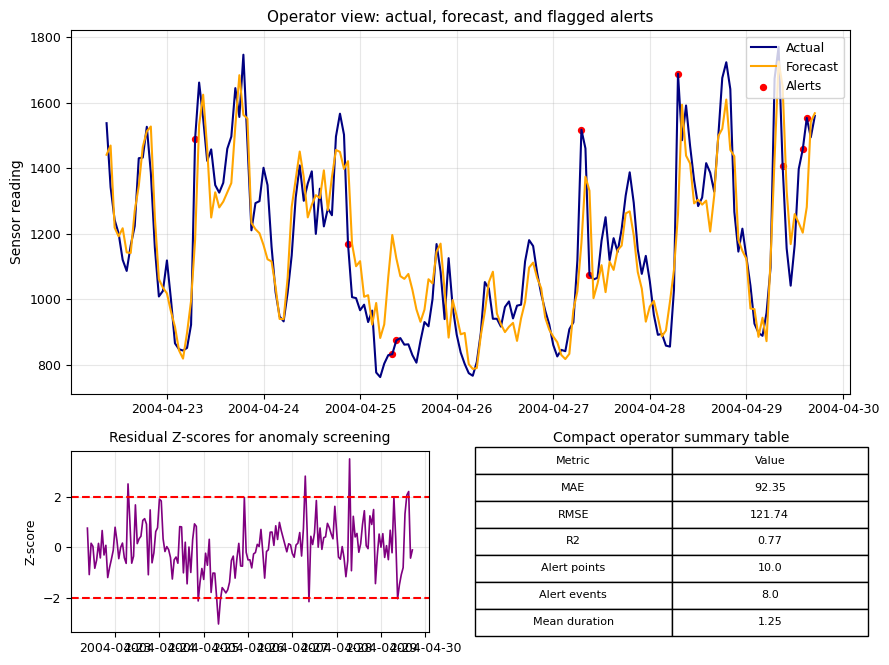

In [23]:
#@title Python Code - Operator Alert Communication

# Download the air quality dataset first.
# Build a small forecasting alert example.
# Communicate results for engineering operators.

# !pip install tensorflow==2.20.0

!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip

# Import quiet libraries for Colab use.
import os, warnings, zipfile, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# Import TensorFlow and metrics tools.
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.metrics import r2_score

tf.get_logger().setLevel('ERROR')
np.random.seed(7)
random.seed(7)

tf.random.set_seed(7)

# Show the framework version briefly.
print('TensorFlow version:', tf.__version__)

# Unzip the downloaded dataset safely.
with zipfile.ZipFile('AirQualityUCI.zip', 'r') as zf:
    zf.extractall('.')

# Load and clean the main table.
raw = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',')
raw = raw.dropna(axis=1, how='all')

raw = raw.dropna(axis=0, how='all')
raw['Date'] = raw['Date'].astype(str).str.strip()
raw['Time'] = raw['Time'].astype(str).str.strip()

raw['DateTime'] = pd.to_datetime(
    raw['Date'] + ' ' + raw['Time'],
    format='%d/%m/%Y %H.%M.%S',

    errors='coerce')
raw = raw.dropna(subset=['DateTime'])

# Replace missing markers and sort time.
raw = raw.replace(-200, np.nan)
raw = raw.sort_values('DateTime').reset_index(drop=True)

raw['PT08.S1(CO)'] = raw['PT08.S1(CO)'].interpolate(limit_direction='both')
series = raw[['DateTime', 'PT08.S1(CO)']].dropna().copy()

# Keep a manageable continuous sample.
series = series.iloc[:1200].copy()
series = series.reset_index(drop=True)

values = series['PT08.S1(CO)'].to_numpy(dtype='float32')

# Create simple lagged forecasting samples.
lookback = 24
X_list = []

y_list = []
for i in range(lookback, len(values)):
    X_list.append(values[i - lookback:i])

    y_list.append(values[i])

# Convert lists into model arrays.
X = np.array(X_list, dtype='float32')
y = np.array(y_list, dtype='float32')

X = X.reshape((X.shape[0], lookback, 1))

# Stop early if data is too small.
if len(X) < 200:
    raise ValueError('Not enough cleaned observations for this example.')

# Split data chronologically for forecasting.
train_end = int(len(X) * 0.7)
val_end = int(len(X) * 0.85)

X_train = X[:train_end]
y_train = y[:train_end]
X_val = X[train_end:val_end]

y_val = y[train_end:val_end]

# Prepare the final test period.
X_test = X[val_end:]
y_test = y[val_end:]

test_time = series['DateTime'].iloc[lookback + val_end:].reset_index(drop=True)

# Scale values using training statistics.
train_mean = X_train.mean()
train_std = X_train.std()

if train_std == 0:
    train_std = 1.0
X_train_s = (X_train - train_mean) / train_std

y_train_s = (y_train - train_mean) / train_std
X_val_s = (X_val - train_mean) / train_std
y_val_s = (y_val - train_mean) / train_std

# Scale the test set similarly.
X_test_s = (X_test - train_mean) / train_std
y_test_s = (y_test - train_mean) / train_std

# Build a lightweight forecasting network.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(lookback, 1)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)])

# Compile and train silently.
model.compile(optimizer='adam', loss='mse')
model.fit(

    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=20, batch_size=32, verbose=0)

# Predict the test period values.
pred_s = model.predict(X_test_s, verbose=0).reshape(-1)
pred = pred_s * train_std + train_mean

# Compute forecast error metrics.
mae = mean_absolute_error(y_test, pred)
rmse = float(np.sqrt(mean_squared_error(y_test, pred)))

r2 = r2_score(y_test, pred)

# Build threshold based anomaly alerts.
residuals = y_test - pred
z_scores = (residuals - residuals.mean()) / (residuals.std() + 1e-6)

alert_mask = np.abs(z_scores) > 2.0

# Count alert events and durations.
alert_count = int(alert_mask.sum())
event_count = 0

durations = []
current = 0
for flag in alert_mask:

    if flag:
        current = current + 1
    else:

        if current > 0:
            event_count = event_count + 1
            durations.append(current)

            current = 0

# Close the final event if needed.
if current > 0:
    event_count = event_count + 1

    durations.append(current)
mean_duration = 0.0
if len(durations) > 0:

    mean_duration = float(np.mean(durations))

# Create operator friendly alert labels.
severity = []
for score in np.abs(z_scores):

    if score > 3.0:
        severity.append('High')
    elif score > 2.0:

        severity.append('Medium')
    else:
        severity.append('Normal')

# Build a compact communication table.
summary = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2', 'Alert points', 'Alert events', 'Mean duration'],

    'Value': [round(mae, 2), round(rmse, 2), round(r2, 2), alert_count, event_count, round(mean_duration, 2)]})

# Prepare a few operator message examples.
alerts = pd.DataFrame({
    'Time': test_time,

    'Actual': y_test,
    'Forecast': pred,
    'Z_score': z_scores,

    'Severity': severity})
alerts = alerts[alert_mask].copy()
alerts = alerts.head(3)

# Print a short operator summary.
print('Target sensor: PT08.S1(CO) hourly signal')
print('Test points:', len(y_test), '| Alert points:', alert_count)

print('MAE:', round(mae, 2), '| RMSE:', round(rmse, 2), '| R2:', round(r2, 2))
if len(alerts) > 0:
    print('Example alert:', alerts.iloc[0]['Severity'], 'deviation near', alerts.iloc[0]['Time'])

else:
    print('Example alert: No threshold breaches in test period')

# Create one dashboard style figure.
fig = plt.figure(figsize=(9, 6.75))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1])

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

# Plot actual and forecast values.
ax1.plot(test_time, y_test, label='Actual', color='navy', linewidth=1.5)
ax1.plot(test_time, pred, label='Forecast', color='orange', linewidth=1.5)

ax1.scatter(test_time[alert_mask], y_test[alert_mask], color='red', s=18, label='Alerts')
ax1.set_title('Operator view: actual, forecast, and flagged alerts', fontsize=11)
ax1.set_ylabel('Sensor reading', fontsize=10)

ax1.tick_params(axis='both', labelsize=9)

ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot residuals with alert thresholds.
ax2.plot(test_time, z_scores, color='purple', linewidth=1.2)
ax2.axhline(2.0, color='red', linestyle='--')

ax2.axhline(-2.0, color='red', linestyle='--')
ax2.set_title('Residual Z-scores for anomaly screening', fontsize=10)
ax2.set_ylabel('Z-score', fontsize=9)

ax2.tick_params(axis='both', labelsize=9)

ax2.grid(True, alpha=0.3)

# Draw the compact summary table.
ax3.axis('off')
table = ax3.table(

    cellText=summary.values,
    colLabels=summary.columns,
    loc='center', cellLoc='center')

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.1, 1.4)

ax3.set_title('Compact operator summary table', fontsize=10)

# Finish the dashboard neatly.
plt.tight_layout()
plt.show()

# <font color="#418FDE" size="6.5" uppercase>**Forecasting and Anomalies**</font>


In this lecture, you learned to:
- Implement simple forecasting models such as naive baselines or ARIMA-style approaches for civil engineering time-series data. 
- Apply basic anomaly detection methods such as Z-score or threshold rules to identify unusual temporal patterns. 
- Evaluate forecasting and anomaly detection results using appropriate error metrics and visual inspection. 

In the next Module (Module 11), we will go over 'Applied Generative AI in Civil Engineering, Part I.'